# Creating an ETL 201 - CPC

# Introduction

Welcome to the [dClimate](https://www.dclimate.net/) Creating an ETL - CPC Jupyter notebook. This notebook describes how to create an [ETL](https://en.wikipedia.org/wiki/Extract,_transform,_load) to ingest GIS data into IPFS from a remote source. If you have not read the [Getting Started](./Getting%20Started.ipynb) notebook we highly suggest you first go through that notebook in order to understand everything below. 

We proceed with first installing fixed versions of `xarray` and `zarr` as the new updates from zarr v3 included in `xarray` and `zarr` break the functionality of the notebook. We are working to resolve this and update this as soon as possible. We additionally install the package `py-hamt` which is responsible for reading and writing zarr data from IPFS. Lastly, we install `etl-scripts` which is a repo that we maintain that already has some prewritten ETLs for PRISM, ERA5 and CPC along with helper functions to assist in the creating new ETLs. It is important to note that writing the ETLs are quite simple as you will see below so do not stress :)

In [22]:
!uv pip install xarray netCDF4 dask zarr multiformats git+https://github.com/dClimate/py-hamt.git@e2cf99cde8a599e224b7be3aa70401dc5b215598 matplotlib

Using Python 3.12.7 environment at: /Users/aristotle/Desktop/work/zarr-getting-started/.venv
Resolved 52 packages in 1.43s                                        
Installed 7 packages in 67ms                                
 + contourpy==1.3.2
 + cycler==0.12.1
 + fonttools==4.58.0
 + kiwisolver==1.4.8
 + matplotlib==3.10.3
 + pillow==11.2.1
 + pyparsing==3.2.3


# Defining the ETL functions

In order to create an ETL there are only 4 main functions to define. It is important to note that these functions are not prescriptive, they only serve as a guide to create a Zarr file that can be ingested into IPFS. You can define any functions but the following pattern will be helpful as you get started. The main steps include:
 - **Pre-fetching data** - create a list of all the datasets that will need to be fetched where the below function allows users to provide a base_url, start_year, and optional end_year
 - **Fetching data** - responsible for fetching all the data that was compiled in the previous pre-fetching step. This data is typically in a format such as NetCDF, Grib or some other binary format that we want to turn into one Zarr.
 - **Transform to Zarr** - aggregate and convert the fetched  data into a Zarr in order to be prepared to ingest it into IPFS
 - **Load Zarr to IPFS** - responsible for adding the Zarr file to IPFS using the `py-hamt` library. A recommended step before the loading should be to standardize the data which is also included, for example ordering dimensions and ensuring that missing data fields are correctly handled. You can do any other transformations you wish.

In [13]:
import os
import pathlib
import xarray as xr
import requests
import subprocess
import zarr.codecs
import numpy as np
from datetime import datetime
from py_hamt import HAMT, KuboCAS
from py_hamt.zarr_hamt_store import ZarrHAMTStore
from multiformats import CID

def prefetch_conus_data(
    base_url: str = "https://psl.noaa.gov/thredds/fileServer/Datasets/cpc_us_precip/RT/precip.V1.0.",
    start_year: int = 2007,
    end_year: int = None,
) -> list[str]:
    """
    Generate a list of netCDF download URLs for CPC CONUS daily precipitation from start_year to end_year.

    :param base_url: Prefix of the data location.
    :param start_year: Earliest year of data to fetch.
    :param end_year: Latest year of data to fetch; defaults to current year if None.
    :return: A list of full download URLs, one per year.
    """
    if end_year is None:
        end_year = datetime.utcnow().year

    download_links = []
    for yr in range(start_year, end_year + 1):
        download_url = f"{base_url}{yr}.nc"
        download_links.append(download_url)

    return download_links


def fetch_data(
    download_links: list[str],
    local_dir: str = "cpc_conus_netcdf",
    overwrite: bool = False,
):
    """
    Download .nc files for each link in download_links.  
    Uses `requests` (though `wget` via `subprocess` is another approach).

    :param download_links: List of full .nc file URLs.
    :param local_dir: Local directory in which to save .nc files.
    :param overwrite: If False, skip download if file exists.
    """
    os.makedirs(local_dir, exist_ok=True)

    for url in download_links:
        filename = url.split("/")[-1]  # e.g. "2007.nc"
        local_path = os.path.join(local_dir, filename)

        if not overwrite and os.path.exists(local_path):
            print(f"File {local_path} exists; skipping download.")
            continue

        print(f"Downloading {url}")
        resp = requests.get(url, stream=True)
        resp.raise_for_status()

        with open(local_path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8192):
                f.write(chunk)

        print(f"Saved to {local_path}")


def transform_to_zarr(
    local_dir: str,
    output_zarr: str,
    varname: str = None,
    start_date: str = None,
    end_date: str = None,
):
    """
    Combine netCDF files from local_dir into a single xarray Dataset, optionally subsetting by date,
    fix missing/fill values, and save to Zarr.

    :param local_dir: Directory containing .nc files, each named like YEAR.nc
    :param output_zarr: Path to the final Zarr store (e.g. "cpc_conus.zarr").
    :param varname: Optional name of the variable to keep. If None, keep all.
    :param start_date: Optional start date (YYYY-MM-DD). If provided, we do xarray’s .sel(time=slice(...)).
    :param end_date: Optional end date (YYYY-MM-DD).
    """
    nc_files = list(pathlib.Path(local_dir).glob("*.nc"))
    if not nc_files:
        raise RuntimeError(f"No netCDF files found in {local_dir}")

    print(f"Reading {len(nc_files)} .nc files from {local_dir}")

    # Within a Jupyter Notebook Context setting parallel=False is to prevent read errors. Parallel reads via Dask can lead to file caching hiccups.
    ds = xr.open_mfdataset([str(f) for f in nc_files], combine="by_coords", parallel=False)

    # If a variable name is provided, keep only that variable.
    if varname is not None and varname in ds.data_vars:
        ds = ds[[varname]]  # subset to that single variable

    # Subset by time if start_date/end_date are provided
    if start_date is not None or end_date is not None:
        time_slice = slice(start_date, end_date)
        ds = ds.sel(time=time_slice)

    # Fix fill values or missing values if they exist
    # ds = _fix_fill_values(ds)
    ds = standardize_and_fix_fill_values(ds)

    # Optionally, you can specify chunk sizes or compression
    # below is a trivial example of chunking by time. Adjust as needed:
    ds = ds.chunk({"time": 30})

    # For demonstration, apply Blosc compression
    for var in ds.data_vars:
        ds[var].encoding["compressors"] = zarr.codecs.BloscCodec()

    print(f"Writing dataset to Zarr => {output_zarr}")
    ds.to_zarr(output_zarr, mode="w")
    print("Zarr creation complete.")


async def load_zarr_to_ipfs(zarr_path: str, cid_out_path: str = None) -> str:
    """
    Put the Zarr store onto IPFS using py-hamt. Returns the root CID as a string.
    If cid_out_path is provided, also write the CID to a file.

    :param zarr_path: Path to the local Zarr directory.
    :param cid_out_path: Optional path to write the CID (e.g. "cpc_conus.cid").
    :return: The root CID string
    """
    print(f"Loading {zarr_path} onto IPFS via py-hamt...")

    kubo_cas = KuboCAS()
    hamt = await HAMT.build(cas=kubo_cas, values_are_bytes=True)
    zhs = ZarrHAMTStore(hamt)

    ds = xr.open_zarr(zarr_path)
    ds.to_zarr(store=zhs, mode="w")

    await hamt.make_read_only()
    root_cid_str = str(hamt.root_node_id)
    print(f"Successfully wrote data to IPFS. Root CID = {root_cid_str}")

    if cid_out_path:
        with open(cid_out_path, "w") as f:
            f.write(root_cid_str + "\n")

    return root_cid_str

def standardize_and_fix_fill_values(ds: xr.Dataset) -> xr.Dataset:
    """
    Renames lat/lon, sorts coordinates, chunks dataset, fixes fill values, and applies compression.
    """
    # 1. Rename lat/lon to standard naming
    ds = ds.rename({"lat": "latitude", "lon": "longitude"})
    
    # 2. Sort coordinates to ascending
    ds = ds.sortby("latitude", ascending=True)
    ds = ds.sortby("longitude", ascending=True)
    
    # 3. Chunk the dataset (choose chunk sizes appropriate to your use case)
    ds = ds.chunk({"time": 1769, "latitude": 24, "longitude": 24})
    
    # 4. Fix fill values for each DataArray in the Dataset
    for var_name, da in ds.data_vars.items():
        
        # Remove any 'missing_value' attribute to avoid conflicts
        if "missing_value" in da.attrs:
            da.attrs.pop("missing_value")

        # Remove 'missing_value' from encoding if it’s there
        if "missing_value" in da.encoding:
            da.encoding.pop("missing_value")

        # Look for an existing _FillValue in the encoding
        fill_val = da.encoding.get("_FillValue", None)
        
        if fill_val is not None:
            # If the data is float/complex, replace the fill_val with NaN
            if da.dtype.kind in ["f", "c"]:
                da = da.where(da != fill_val, float("nan"))
                ds[var_name] = da  # Reassign back after masking
                da.encoding["_FillValue"] = float("nan")
            else:
                # Keep the integer fill value for integer data
                da.encoding["_FillValue"] = fill_val
        else:
            # If there's no _FillValue and it's float data, set _FillValue to NaN
            if da.dtype.kind in ["f", "c"]:
                da.encoding["_FillValue"] = float("nan")

    return ds

After defining the various ETL steps above, it is simply a matter of calling each step in a sequential fashion. In the logs you should see the files being fetched for the dates provided. 

As you can see, 2007 is given as a start year and 2008 as an end year which is inclusive, and therefore will download the NetCDF files for both years(2007 and 2008). The data is then fetched, however, if the data already already exists locally it will not be downloaded again if the `overwrite` flag is set to false. The next step is to transform the netcdf files to zarr where the `end_date` only includes the first day of 2008 for example sake. Additionally if a `varname` is provided only that variable will be kept on the zarr. 

Lastly `load_zarr_to_ipfs` will return a CID (read the [Getting Started](./Getting%20Started.ipynb) to learn more) and write it out once the pipeline has completed.

In [14]:
# Example usage of the modular ETL pipeline

# 1. Generate the list of CPC CONUS precipitation .nc URLs (only for years 2007 and 2008, end year is inclusive)
download_links = prefetch_conus_data(
    start_year=2007,
    end_year=2008,  # If you want multiple years, pass a larger end_year
)

# 2. Download the actual .nc files
fetch_data(
    download_links=download_links,
    local_dir="downloaded_data/gis/cpc_conus_netcdf_demo",
    overwrite=False,  # set True if you want to re-download
)

# 3. Transform the .nc files to Zarr, but only keep the first year 
transform_to_zarr(
    local_dir="downloaded_data/gis/cpc_conus_netcdf_demo",
    output_zarr="output_data/gis/cpc_conus_demo.zarr",
    varname="precip",         # If you don't know the exact var name, you can omit varname
    start_date="2007-01-01",  # Only keep data from Jan 1
    end_date="2008-01-01",    # through Jan 1 of 2008 (only includes day one from the second file)
)

# 4. Put the new "cpc_conus_demo.zarr" on IPFS
root_cid = await load_zarr_to_ipfs(
    zarr_path="output_data/gis/cpc_conus_demo.zarr",
    cid_out_path="output_data/gis/cpc_conus_demo.cid"
)

print(f"Pipeline complete! The root CID is {root_cid}")

File downloaded_data/gis/cpc_conus_netcdf_demo/precip.V1.0.2007.nc exists; skipping download.
File downloaded_data/gis/cpc_conus_netcdf_demo/precip.V1.0.2008.nc exists; skipping download.
Reading 2 .nc files from downloaded_data/gis/cpc_conus_netcdf_demo
Writing dataset to Zarr => output_data/gis/cpc_conus_demo.zarr


/Users/aristotle/Desktop/work/zarr-getting-started/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Zarr creation complete.
Loading output_data/gis/cpc_conus_demo.zarr onto IPFS via py-hamt...


/Users/aristotle/Desktop/work/zarr-getting-started/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:213: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Successfully wrote data to IPFS. Root CID = bafyr4ic74x7txr2zleqvurhyaw2gkprtm6hbt654vijj7l7uela3mptcqy
Pipeline complete! The root CID is bafyr4ic74x7txr2zleqvurhyaw2gkprtm6hbt654vijj7l7uela3mptcqy


# Opening and Reading the Dataset

As you can see below, in a similar fashion to the Getting Started Notebook, we go ahead and provide the root hash(CID) of the newly ingested dataset into the HAMT store which is then loaded by xarray.

In [19]:
import xarray as xr
from py_hamt import HAMT, KuboCAS
from py_hamt.zarr_hamt_store import ZarrHAMTStore
from multiformats import CID

decoded_root_cid = CID.decode(root_cid)
print("Decoded CID from above:", decoded_root_cid)

kubo_cas = KuboCAS()

# Create HAMT instance using the IPFSStore connecting to your locally running IPFS Gateway from your local running IPFS Node
hamt = await HAMT.build(cas=kubo_cas, root_node_id=decoded_root_cid, values_are_bytes=True, read_only=True)
zhs = ZarrHAMTStore(hamt, read_only=True)

ds = xr.open_zarr(store=zhs)
print(ds)

Decoded CID from above: bafyr4ic74x7txr2zleqvurhyaw2gkprtm6hbt654vijj7l7uela3mptcqy
<xarray.Dataset> Size: 53MB
Dimensions:    (time: 366, latitude: 120, longitude: 300)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2007-01-01 2007-01-02 ... 2008-01-01
  * latitude   (latitude) float32 480B 20.12 20.38 20.62 ... 49.38 49.62 49.88
  * longitude  (longitude) float32 1kB 230.1 230.4 230.6 ... 304.4 304.6 304.9
Data variables:
    precip     (time, latitude, longitude) float32 53MB dask.array<chunksize=(30, 24, 24), meta=np.ndarray>
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    history:        originally created RT starting 04/2010 by CAS from data o...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Reference

We demonstrate below that every value is included from the first year of 2007 and of the first day of 2008 as described in the ETL steps provided above.

In [20]:
print(ds.time.values)

['2007-01-01T00:00:00.000000000' '2007-01-02T00:00:00.000000000'
 '2007-01-03T00:00:00.000000000' '2007-01-04T00:00:00.000000000'
 '2007-01-05T00:00:00.000000000' '2007-01-06T00:00:00.000000000'
 '2007-01-07T00:00:00.000000000' '2007-01-08T00:00:00.000000000'
 '2007-01-09T00:00:00.000000000' '2007-01-10T00:00:00.000000000'
 '2007-01-11T00:00:00.000000000' '2007-01-12T00:00:00.000000000'
 '2007-01-13T00:00:00.000000000' '2007-01-14T00:00:00.000000000'
 '2007-01-15T00:00:00.000000000' '2007-01-16T00:00:00.000000000'
 '2007-01-17T00:00:00.000000000' '2007-01-18T00:00:00.000000000'
 '2007-01-19T00:00:00.000000000' '2007-01-20T00:00:00.000000000'
 '2007-01-21T00:00:00.000000000' '2007-01-22T00:00:00.000000000'
 '2007-01-23T00:00:00.000000000' '2007-01-24T00:00:00.000000000'
 '2007-01-25T00:00:00.000000000' '2007-01-26T00:00:00.000000000'
 '2007-01-27T00:00:00.000000000' '2007-01-28T00:00:00.000000000'
 '2007-01-29T00:00:00.000000000' '2007-01-30T00:00:00.000000000'
 '2007-01-31T00:00:00.000

# Plotting the Data

To illustrate the data we go ahead and plot some of the precipitation information for New York :)

<xarray.Dataset> Size: 56kB
Dimensions:    (time: 366, latitude: 18, longitude: 2)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2007-01-01 2007-01-02 ... 2008-01-01
  * latitude   (latitude) float32 72B 40.62 40.88 41.12 ... 44.38 44.62 44.88
  * longitude  (longitude) float32 8B 285.9 286.1
Data variables:
    precip     (time, latitude, longitude) float32 53kB dask.array<chunksize=(30, 14, 2), meta=np.ndarray>
Attributes:
    title:          CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    Conventions:    COARDS
    description:    Gridded daily Precipitation
    platform:       Observations
    Comments:       Preciptation is accumulated from 12z of previous day to 1...
    history:        originally created RT starting 04/2010 by CAS from data o...
    dataset_title:  CPC Unified Gauge-Based Analysis of Daily Precipitation o...
    References:     http://www.psl.noaa.gov/data/gridded/data.unified.daily.c...
Precipitation data exists for this range.


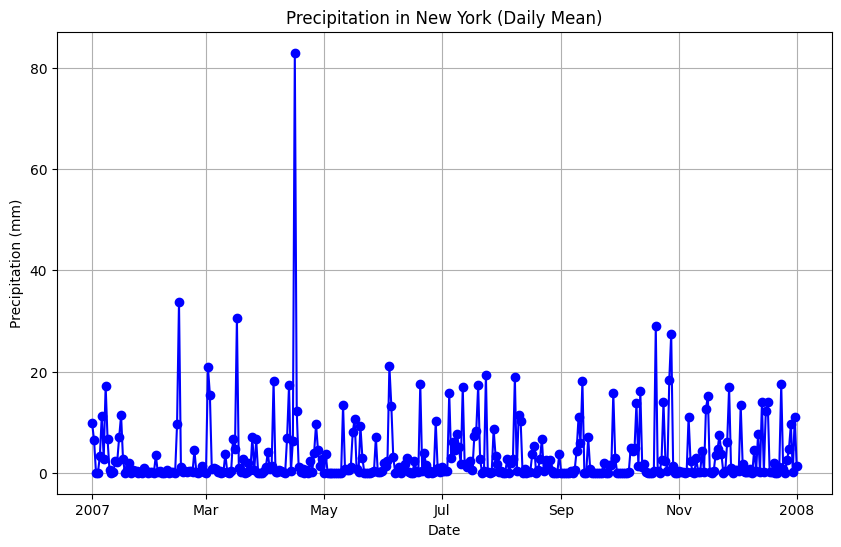

In [23]:
import matplotlib.pyplot as plt

lon_range = (360 - 74.25, 360 - 73.7)  # Converted to 285.75 - 286.3
lat_range = (40.5, 45.0)  # Latitude remains the same

ny_precip = ds.sel(latitude=slice(*lat_range), longitude=slice(*lon_range))
print(ny_precip)

if ny_precip.precip.count() > 0:
    print("Precipitation data exists for this range.")
else:
    print("No precipitation data for the specified range.")

# Compute the average precipitation over the region
ny_precip_mean = ny_precip.precip.mean(dim=["latitude", "longitude"])

# Plot the data
plt.figure(figsize=(10, 6))
ny_precip_mean.plot(marker='o', color='blue')
plt.title("Precipitation in New York (Daily Mean)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()